# Multiple Tokamak Comparison

## Overview

VAFT is built as machine-agnostic tokamak infrastructure with VEST as its
reference implementation. This notebook tests that claim against data VAFT does
not own: publicly released equilibria from seven devices, fetched from their
upstream repositories at run time, loaded through one VAFT entry point, and
compared in one set of axes.

The workflow is

```text
public upstream dataset -> fetch -> vaft.omas.load -> ODS -> validation -> cross-machine comparison
```

Only VEST's dataset ships with VAFT. The other six are downloaded from the
public repositories that publish them. Nothing here is vendored into VAFT, and
this notebook is deliberately **not** a dataset registry: the sources below are
plain variables with their alternatives commented out beneath them.

## Public data sources

| Device | Source | Format | Dataset type |
| --- | --- | --- | --- |
| VEST | VAFT packaged sample, shot 39915 | IMAS netCDF | experimental |
| DIII-D | [FUSE.jl](https://github.com/ProjectTorreyPines/FUSE.jl/tree/master/sample) | ODS JSON | reference equilibrium |
| MAST-U | [FUSE.jl](https://github.com/ProjectTorreyPines/FUSE.jl/tree/master/sample) | ODS JSON | reference H-mode |
| JET | [FUSE.jl](https://github.com/ProjectTorreyPines/FUSE.jl/tree/master/sample) | ODS JSON | reference equilibrium |
| TCV | [TCV-X21](https://github.com/SPCData/TCV-X21/tree/main/1.experimental_data) | GEQDSK | experimental equilibrium |
| SPARC | [SPARCPublic](https://github.com/cfs-energy/SPARCPublic/tree/main/EQlibrary) | GEQDSK | design / reference |
| ITER | [FUSE.jl](https://github.com/ProjectTorreyPines/FUSE.jl/tree/master/sample) | ODS JSON | design / reference |

The dataset types are kept distinct on purpose. VEST 39915 and TCV 65402 are
measured discharges. The DIII-D, MAST-U and JET files are reference scenarios
distributed with a modelling framework. SPARC's `EQlibrary` and the ITER
equilibrium are **design** cases for devices that have not operated -- SPARC's
are ramp-up scenarios, not measurements. Nothing in this notebook is synthetic.

## 1. Fetch

Upstream failures and VAFT failures are kept apart. A dead URL raises
`FetchError` and is reported as a fetch problem; anything raised by
`vaft.omas.load` is reported as a load problem. Downloads land in the system
temporary directory, so the checkout stays clean and a re-run on the same
machine does not pull the files again.

In [ ]:
import tempfile
import urllib.error
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import vaft
from vaft.process.equilibrium import (
    as_equilibrium,
    convert_cocos,
    derive_global_descriptors,
)

CACHE = Path(tempfile.gettempdir()) / "vaft-open-data"
CACHE.mkdir(parents=True, exist_ok=True)


class FetchError(RuntimeError):
    """The upstream URL could not be retrieved -- not a VAFT loader defect."""


def fetch(url, *, timeout=120):
    """Download ``url`` into the temporary cache and return the local path."""
    target = CACHE / url.rsplit("/", 1)[-1]
    if not target.exists():
        try:
            with urllib.request.urlopen(url, timeout=timeout) as response:
                payload = response.read()
        except (urllib.error.URLError, OSError, ValueError) as error:
            raise FetchError(f"{url}: {error}") from error
        target.write_bytes(payload)
    return target


print("cache:", CACHE)

cache: <tmp>


## 2. Sources

One default dataset per device. Alternatives published by the same upstream
repository are kept as commented lines so a reader can switch by hand -- that is
the whole switching mechanism, by design.

VEST is the native case and needs no network: `vaft.data.sample` returns the
IMAS netCDF that ships with the library.

In [ ]:
# VEST -- packaged with VAFT, no download.
vest_source = vaft.data.sample(39915, representation="imas")
# alternatives:
# vest_source = vaft.data.sample(41524, representation="imas")
# vest_source = vaft.data.sample(41672, representation="imas")
# vest_source = vaft.data.data_path("efit/g039915.00319")  # bundled GEQDSK

FUSE = "https://raw.githubusercontent.com/ProjectTorreyPines/FUSE.jl/master/sample/"
OMAS_SAMPLES = "https://raw.githubusercontent.com/gafusion/omas/master/omas/samples/"

# DIII-D -- FUSE equilibrium ODS.
d3d_url = FUSE + "D3D_eq_ods.json"
# alternatives:
# d3d_url = FUSE + "D3D_standard_Hmode.json"
# d3d_url = FUSE + "D3D_standard_Lmode.json"
# d3d_url = OMAS_SAMPLES + "g145419.02100"

# MAST-U -- FUSE reference H-mode.
mastu_url = FUSE + "MASTU_Hmode.json"
# alternatives:
# mastu_url = FUSE + "MASTU_machine.json"

# JET -- FUSE shot 99948 equilibrium.
jet_url = FUSE + "JET_99948_STATE0_eq.json"

# TCV -- TCV-X21 reference scenario, shot 65402 at t = 1.0 s.
tcv_url = (
    "https://raw.githubusercontent.com/SPCData/TCV-X21/main/"
    "1.experimental_data/reference_scenario/65402_t1.eqdsk"
)

# ITER -- FUSE design equilibrium, 15 MA baseline scenario.
iter_url = FUSE + "ITER_equilibrium_ods.json"
# alternatives (machine description rather than equilibrium):
# iter_url = FUSE + "ITER_wall_ods.json"
# iter_url = FUSE + "ITER_pf_active_ods.json"

# SPARC -- public design equilibrium library. The file name is the upstream
# convention statement: psi/2pi, negative Ip, negative Bt, negative F.
sparc_url = (
    "https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/"
    "EQlibrary/sparc_1593.EQDSK_PsiOver2pi_negIp_negBt_negFpol"
)
# alternatives:
# sparc_url = ("https://raw.githubusercontent.com/cfs-energy/SPARCPublic/main/"
#              "DeviceDescription/OS_SPARC_Device_Description.json")

DATASETS = (
    ("VEST", vest_source, "IMAS netCDF", "experimental"),
    ("DIII-D", d3d_url, "ODS JSON", "reference equilibrium"),
    ("MAST-U", mastu_url, "ODS JSON", "reference H-mode"),
    ("JET", jet_url, "ODS JSON", "reference equilibrium"),
    ("TCV", tcv_url, "GEQDSK", "experimental equilibrium"),
    ("SPARC", sparc_url, "GEQDSK", "design / reference"),
    ("ITER", iter_url, "ODS JSON", "design / reference"),
)

## 3. Load into a common ODS

`vaft.omas.load` is the single entry point for all three formats. It identifies
the source by content rather than by file name, which is why SPARC's
`…EQDSK_PsiOver2pi_negIp_negBt_negFpol` and TCV's `65402_t1.eqdsk` need no
renaming, and why the IMAS netCDF, the ODS JSON files and the GEQDSK files all
arrive as an `ODS` without per-format handling here.

A device that fails is recorded and skipped. Nothing below aborts the notebook.

In [ ]:
cases, kinds, status = {}, {}, {}

for device, source, fmt, kind in DATASETS:
    try:
        path = source if isinstance(source, Path) else fetch(source)
    except FetchError as error:
        status[device] = f"fetch failed -- {error}"
        continue
    try:
        cases[device] = vaft.omas.load(path)
    except Exception as error:  # a loader defect, not an upstream outage
        status[device] = f"load failed -- {type(error).__name__}: {error}"
        continue
    kinds[device] = (fmt, kind)
    status[device] = f"loaded from {fmt}"

for device, _, _, _ in DATASETS:
    print(f"{device:8s} {status[device]}")

10:59:17 INFO     Parsing data dictionary version 3.41.0 @dd_zip.py:89


<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0
<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for geqdsk; using 3.41.0
<repo>/vaft/process/_equilibrium_parametric.py:318: RuntimeWarning: g-file BCENTR=-0.92864 T disagrees with FPOL[-1]/RCENTR=-0.932369 T (FPOL[-1]=-0.820485 T.m, RCENTR=0.88 m); using the FPOL value, which is the field the equilibrium was solved with (issue #325)


<repo>/vaft/database/_local.py:236: RuntimeWarning: g-file BCENTR=-0.92864 T disagrees with FPOL[-1]/RCENTR=-0.932369 T (FPOL[-1]=-0.820485 T.m, RCENTR=0.88 m); using the FPOL value, which is the field the equilibrium was solved with (issue #325)


VEST     loaded from IMAS netCDF
DIII-D   loaded from ODS JSON
MAST-U   loaded from ODS JSON
JET      loaded from ODS JSON
TCV      loaded from GEQDSK
SPARC    loaded from GEQDSK
ITER     loaded from ODS JSON


## 4. What each dataset actually carries

A smoke test, not an interpretation: which IDSs came through, what the dataset
says about itself, and whether an equilibrium is present and usable. Quantities
are read through `vaft.process.equilibrium.derive_global_descriptors`, which
returns each value with its unit, provenance and availability, so a quantity
that the source does not carry prints as `--` instead of being invented.

In [ ]:
def peak_index(ods):
    """Slice with the largest |Ip|; VEST carries nine, the others carry one."""
    slices = ods["equilibrium.time_slice"]
    currents = [
        abs(float(slices[i]["global_quantities.ip"]))
        if "ip" in slices[i]["global_quantities"]
        else float("nan")
        for i in range(len(slices))
    ]
    finite = np.isfinite(currents)
    return int(np.nanargmax(currents)) if finite.any() else 0


def show(item, digits=3):
    """Format a DerivedValue, keeping unavailable quantities unavailable."""
    if not item.available:
        return "--"
    return f"{float(item.value):.{digits}g}"


equilibria, descriptors, indices = {}, {}, {}
for device, ods in cases.items():
    if "equilibrium" not in ods or len(ods["equilibrium.time_slice"]) == 0:
        print(f"{device}: no equilibrium IDS -- skipped for the comparisons below")
        continue
    indices[device] = peak_index(ods)
    equilibria[device] = as_equilibrium(ods, time_index=indices[device])
    descriptors[device] = derive_global_descriptors(equilibria[device])

header = (
    f"{'device':8s} {'type':24s} {'slices':>6s} {'used':>4s} {'t [s]':>8s} "
    f"{'grid':>9s} {'axis R,Z [m]':>18s} {'Ip [kA]':>9s} {'B0 [T]':>7s}  IDSs"
)
print(header)
print("-" * len(header))
for device in cases:
    ods = cases[device]
    ids_list = ",".join(sorted(ods.keys()))
    n_slices = len(ods["equilibrium.time_slice"]) if "equilibrium" in ods else 0
    eq = equilibria.get(device)
    desc = descriptors.get(device)
    grid = f"{eq.r.size}x{eq.z.size}" if eq is not None and eq.r is not None else "--"
    axis = (
        f"({eq.magnetic_axis[0]:.3f}, {eq.magnetic_axis[1]:+.3f})"
        if eq is not None and eq.magnetic_axis is not None
        else "--"
    )
    time = f"{eq.time:.3f}" if eq is not None and eq.time is not None else "--"
    ip = f"{float(desc['ip'].value) / 1e3:.1f}" if desc and desc["ip"].available else "--"
    b0 = show(desc["bt0"]) if desc else "--"
    print(
        f"{device:8s} {kinds[device][1]:24s} {n_slices:6d} "
        f"{indices.get(device, 0):4d} {time:>8s} {grid:>9s} {axis:>18s} "
        f"{ip:>9s} {b0:>7s}  {ids_list}"
    )

device   type                     slices used    t [s]      grid       axis R,Z [m]   Ip [kA]  B0 [T]  IDSs
-----------------------------------------------------------------------------------------------------------
VEST     experimental                  9    0    0.316   129x129    (0.427, +0.023)      80.1    0.15  barometry,dataset_description,equilibrium,magnetics,pf_active,pf_passive,spectrometer_uv,tf,wall
DIII-D   reference equilibrium         1    0    1.000     65x65    (1.732, -0.025)    1083.7   -1.71  dataset_description,equilibrium,wall
MAST-U   reference H-mode              1    0    0.006     51x51    (0.997, +0.002)     744.5  -0.562  core_profiles,core_sources,equilibrium,summary,wall
JET      reference equilibrium         1    0    0.000   129x129    (3.002, +0.354)   -3428.5   -3.39  core_profiles,core_sources,dataset_description,equilibrium,summary,wall
TCV      experimental equilibrium      1    0    0.000   400x600    (0.909, -0.008)    -145.9  -0.932  dataset_des

Machine and pulse metadata is carried by `dataset_description` when the upstream
file provides one. GEQDSK inputs have no such record beyond what VAFT infers
from the file, and the FUSE reference scenarios identify themselves only
loosely; both are reported as they are.

In [ ]:
for device, ods in cases.items():
    entry = ods["dataset_description.data_entry"] if "dataset_description" in ods else {}
    machine = entry["machine"] if "machine" in entry else "--"
    pulse = entry["pulse"] if "pulse" in entry else "--"
    comment = "--"
    if "equilibrium" in ods and "ids_properties" in ods["equilibrium"]:
        properties = ods["equilibrium.ids_properties"]
        if "comment" in properties:
            comment = str(properties["comment"]).strip() or "--"
    print(f"{device:8s} machine={machine!s:10s} pulse={pulse!s:10s} equilibrium comment={comment}")

VEST     machine=VEST       pulse=39915      equilibrium comment=EFIT     02/26/2026    # 39915   331ms           0 129
DIII-D   machine=D3D        pulse=133221     equilibrium comment=EFITD
MAST-U   machine=--         pulse=--         equilibrium comment=TRXfb 18
JET      machine=gasc       pulse=0          equilibrium comment=EFIT
TCV      machine=--         pulse=0          equilibrium comment=TCV LIUQE.M #65402 t= 1  07-May-202                3
SPARC    machine=--         pulse=1          equilibrium comment=EFIT    xx/xx/xxxx    #1  1ms           3
ITER     machine=ITER       pulse=--         equilibrium comment=EFITD


Plot availability is decided per dataset rather than assumed. The catalog below
counts the canonical VAFT plots whose required data is present in each ODS --
VEST carries diagnostics the imported equilibria simply do not have, and that
difference is data, not an error.

In [ ]:
for device, ods in cases.items():
    catalog = vaft.omas.available_plots(ods)
    print(f"{device:8s} {len(list(catalog)):3d} plots available")

VEST      53 plots available
DIII-D    24 plots available
MAST-U    30 plots available
JET       37 plots available
TCV       20 plots available
SPARC     20 plots available
ITER      24 plots available


## 5. Equilibrium geometry

Two views of the same boundaries. The physical `R-Z` view shows the size
difference the devices actually have; the normalized view, `(R - R0) / a`
against `Z / a`, removes it so that shape can be compared -- which is the only
way the spherical tokamaks (VEST, MAST-U) and the conventional aspect-ratio
machines (DIII-D, JET, SPARC) sit usefully in one axes.

Boundaries come from `EquilibriumData.lcfs`, which VAFT populated from whichever
format the device was published in.

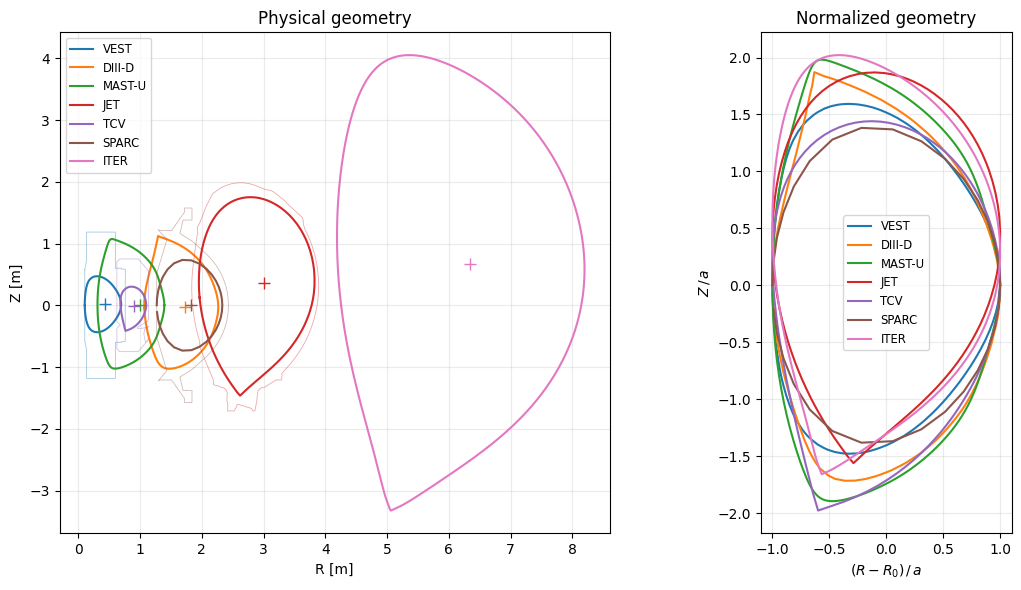

In [ ]:
fig, (ax_physical, ax_normalized) = plt.subplots(1, 2, figsize=(12, 6))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for color, (device, eq) in zip(colors, equilibria.items()):
    if eq.lcfs is None:
        print(f"{device}: no LCFS -- skipped")
        continue
    desc = descriptors[device]
    ax_physical.plot(eq.lcfs.r, eq.lcfs.z, color=color, label=device)
    if eq.limiter is not None:
        ax_physical.plot(eq.limiter.r, eq.limiter.z, color=color, lw=0.6, alpha=0.4)
    if eq.magnetic_axis is not None:
        ax_physical.plot(*eq.magnetic_axis, marker="+", color=color, ms=8)
    if desc["major_radius"].available and desc["minor_radius"].available:
        r0 = float(desc["major_radius"].value)
        a = float(desc["minor_radius"].value)
        ax_normalized.plot((eq.lcfs.r - r0) / a, eq.lcfs.z / a, color=color, label=device)
    else:
        print(f"{device}: R0/a unavailable -- omitted from the normalized view")

ax_physical.set(xlabel="R [m]", ylabel="Z [m]", title="Physical geometry")
ax_normalized.set(
    xlabel=r"$(R - R_0)\,/\,a$", ylabel=r"$Z\,/\,a$", title="Normalized geometry"
)
for ax in (ax_physical, ax_normalized):
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

The canonical VAFT renderer draws the same boundary from any of these ODSs
without device-specific code:

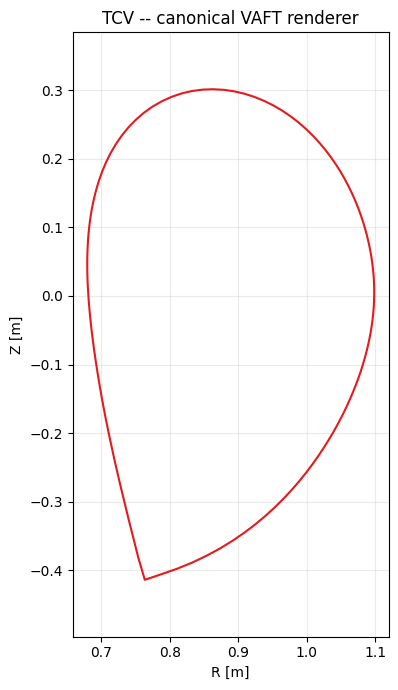

In [ ]:
demo = "TCV" if "TCV" in equilibria else next(iter(equilibria), None)
if demo is None:
    print("no equilibrium loaded -- nothing to render")
else:
    figure, axes = vaft.omas.plot_equilibrium_geometry_boundary(
        cases[demo],
        label=[demo],
        time_slice=indices[demo],
        title=f"{demo} -- canonical VAFT renderer",
    )
    plt.show()

It draws **one** dataset, though. `vaft.omas.plot_equilibrium_geometry_boundary`
accepts a list of ODSs, but the geometry recipe renders the first entry only,
with a fixed colour and no per-entry label -- unlike the profile renderers used
below, which overlay every entry. That is why the two-panel comparison above is
drawn directly from `EquilibriumData` rather than through the canonical
renderer. It is a gap in the plotting layer, not a VEST-specific assumption:
nothing in the geometry path rejected foreign-machine data. A multi-machine
geometry overview API is listed as follow-up work in the issue this notebook
implements.

## 6. Global quantities

Every column comes from the same convention-aware derivation, and an unavailable
quantity stays unavailable. The `q95` column is shown as stored, before the
convention normalization of the next section -- which is exactly why its sign is
not comparable yet.

In [ ]:
columns = (
    ("Ip [kA]", "ip", 1e-3),
    ("B0 [T]", "bt0", 1.0),
    ("R0 [m]", "major_radius", 1.0),
    ("a [m]", "minor_radius", 1.0),
    ("eps", "inverse_aspect_ratio", 1.0),
    ("kappa", "elongation", 1.0),
    ("delta_u", "triangularity_upper", 1.0),
    ("delta_l", "triangularity_lower", 1.0),
    ("V [m^3]", "volume", 1.0),
    ("q95", "q95", 1.0),
)

head = f"{'device':8s}" + "".join(f"{name:>10s}" for name, _, _ in columns)
print(head)
print("-" * len(head))
for device, desc in descriptors.items():
    row = f"{device:8s}"
    for _, key, scale in columns:
        item = desc[key]
        row += f"{'--':>10s}" if not item.available else f"{float(item.value) * scale:>10.3g}"
    print(row)

print()
print("Provenance of the elongation column:")
for device, desc in descriptors.items():
    item = desc["elongation"]
    method = item.provenance.method if item.available else "unavailable"
    print(f"  {device:8s} {method:12s} {item.definition}")

device     Ip [kA]    B0 [T]    R0 [m]     a [m]       eps     kappa   delta_u   delta_l   V [m^3]       q95
------------------------------------------------------------------------------------------------------------
VEST          80.1      0.15     0.399     0.295     0.739      1.54      0.33      0.33     0.956      8.67
DIII-D    1.08e+03     -1.71      1.67     0.599     0.359      1.79     0.632     0.361      19.1     -4.36
MAST-U         744    -0.562     0.851     0.541     0.636      1.94     0.564     0.467      8.59     -6.17
JET      -3.43e+03     -3.39      2.89     0.937     0.324      1.72     0.101     0.288        78      3.19
TCV           -146    -0.932     0.889     0.209     0.235      1.71     0.123     0.599      1.22      3.33
SPARC       -3e+03     -12.2       1.8     0.531     0.295      1.38     0.218     0.218      13.6     -4.85
ITER      1.52e+04     -5.06      6.19         2     0.324      1.84     0.415     0.566       807     -3.17

Provenance of the 

## 7. COCOS and sign conventions

Cross-machine equilibrium comparison is where sign conventions stop being an
abstraction. VAFT identifies each source's convention from its own signs rather
than assuming one, and reports ambiguity instead of hiding it: a GEQDSK whose
signs are consistent with both COCOS 1 and 11 differs only in whether psi is per
radian, which the file itself does not state.

SPARC is the clearest case -- the upstream file name declares
`PsiOver2pi_negIp_negBt_negFpol`, and VAFT independently identifies COCOS 13/14
from the data.

In [ ]:
print(f"{'device':8s} {'candidates':>16s} {'psi/rad':>8s} {'sgn(Ip)':>8s} {'sgn(Bt)':>8s} {'sgn(q)':>7s}  evidence")
for device, eq in equilibria.items():
    convention = eq.convention
    print(
        f"{device:8s} {str(convention.identified):>16s} {str(convention.psi_per_radian):>8s} "
        f"{convention.ip_sign!s:>8s} {convention.bt_sign!s:>8s} {convention.q_sign!s:>7s}  {convention.source}"
    )

print()
for device, desc in descriptors.items():
    issues = [issue.message for issue in desc.validation.issues]
    print(f"{device:8s} {issues if issues else 'no validation issues'}")

device         candidates  psi/rad  sgn(Ip)  sgn(Bt)  sgn(q)  evidence
VEST               (1, 2)     True        1        1       1  ODS signs + phi/q slope family detection
DIII-D           (11, 12)    False        1       -1      -1  ODS signs + phi/q slope family detection
MAST-U     (1, 2, 11, 12)    False        1       -1      -1  ODS signs + phi/q slope family detection
JET              (11, 12)    False       -1       -1       1  ODS signs + phi/q slope family detection
TCV        (1, 2, 11, 12)    False       -1       -1       1  ODS signs + phi/q slope family detection
SPARC            (13, 14)    False       -1       -1      -1  ODS signs + phi/q slope family detection
ITER             (11, 12)    False        1       -1      -1  ODS signs + phi/q slope family detection

VEST     ['COCOS is ambiguous ((1, 2)); pass convention= explicitly before conversion']
DIII-D   ['COCOS is ambiguous ((11, 12)); pass convention= explicitly before conversion']
MAST-U   ['COCOS is ambiguous

Where the identification is ambiguous the notebook picks the first candidate and
says so, rather than letting a silent default decide. Everything is then
converted to COCOS 11 through the existing
`vaft.process.equilibrium.convert_cocos` path before any sign-sensitive
comparison.

In [ ]:
normalized = {}
for device, ods in cases.items():
    if device not in equilibria:
        continue
    candidates = equilibria[device].convention.identified
    if not candidates:
        print(f"{device:8s} convention unidentified -- left as stored")
        continue
    source_cocos = candidates[0]
    note = "" if len(candidates) == 1 else f"  (ambiguous {candidates}, took the first)"
    stated = as_equilibrium(ods, time_index=indices[device], convention=source_cocos)
    normalized[device] = convert_cocos(stated, 11)
    q_before = float(stated.q[0]) if stated.q is not None else float("nan")
    q_after = float(normalized[device].q[0]) if normalized[device].q is not None else float("nan")
    print(f"{device:8s} COCOS {source_cocos:>2d} -> 11   q(axis) {q_before:+.3f} -> {q_after:+.3f}{note}")

VEST     COCOS  1 -> 11   q(axis) +2.460 -> +2.460  (ambiguous (1, 2), took the first)
DIII-D   COCOS 11 -> 11   q(axis) -1.410 -> -1.410  (ambiguous (11, 12), took the first)
MAST-U   COCOS  1 -> 11   q(axis) -1.177 -> -1.177  (ambiguous (1, 2, 11, 12), took the first)
JET      COCOS 11 -> 11   q(axis) +0.895 -> +0.895  (ambiguous (11, 12), took the first)
TCV      COCOS  1 -> 11   q(axis) +1.234 -> +1.234  (ambiguous (1, 2, 11, 12), took the first)
SPARC    COCOS 13 -> 11   q(axis) -1.202 -> +1.202  (ambiguous (13, 14), took the first)
ITER     COCOS 11 -> 11   q(axis) -1.064 -> -1.064  (ambiguous (11, 12), took the first)


## 8. Profiles

The profile renderers do overlay every entry, so this comparison uses the
canonical VAFT API directly, on normalized poloidal flux -- the one radial
coordinate every dataset here can supply. Datasets are included per quantity:
one that lacks a profile is named and skipped rather than forced onto the axes.

The panels are drawn with VAFT's display sign policy set to `intuitive`, which
multiplies each dataset by one `+1`/`-1` so its dominant response is positive,
per entry and never per sample, and says so in the title when it flipped. `q`
takes that policy by default -- its stored sign is the source's COCOS and
nothing else -- while `F dF/dpsi` and `dp/dpsi` are asked for it explicitly here,
because their sign also carries a gradient direction that is worth keeping in a
single-machine view. `F = R B_t` is left as stored: its sign is the toroidal
field direction, a property of the machine rather than of the file format.

The data itself is untouched by any of this. The physical version of the same
comparison is the COCOS-normalized panel in the next cell.

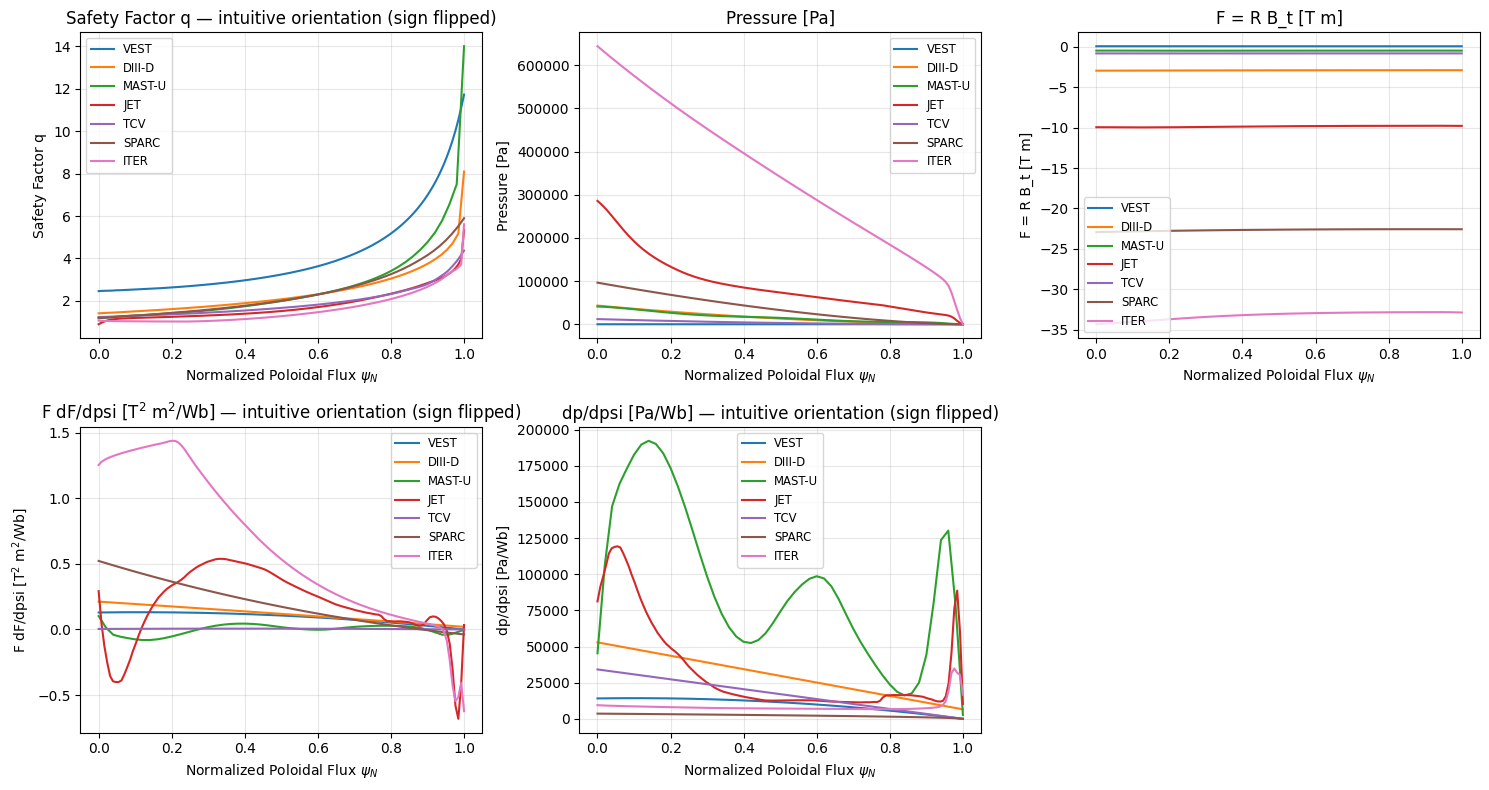

In [ ]:
profile_plots = (
    ("q", vaft.omas.plot_equilibrium_profile_q),
    ("pressure", vaft.omas.plot_equilibrium_profile_pressure),
    ("f", vaft.omas.plot_equilibrium_profile_f),
    ("ffprime", vaft.omas.plot_equilibrium_profile_ffprime),
    ("pprime", vaft.omas.plot_equilibrium_profile_pprime),
)
attribute = {"q": "q", "pressure": "pressure", "f": "f", "ffprime": "ffprime", "pprime": "pprime"}

# q already defaults to intuitive; F keeps the machine's toroidal field sign.
orientations = {"q": "intuitive", "pressure": "canonical", "f": "canonical",
                "ffprime": "intuitive", "pprime": "intuitive"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, plot) in zip(axes.ravel(), profile_plots):
    entries, labels = [], []
    for device, eq in equilibria.items():
        if getattr(eq, attribute[name]) is None:
            print(f"{device}: no {name} profile -- skipped")
            continue
        entries.append(cases[device])
        labels.append(device)
    plot(
        entries,
        label=labels,
        coordinate="psi_norm",
        orientation=orientations[name],
        ax=ax,
    )
axes.ravel()[-1].axis("off")
fig.tight_layout()
plt.show()

Display orientation is not a convention conversion: it makes curves comparable
by eye, and deliberately discards the sign it flipped. The physical statement is
the one below -- `q` from the COCOS-11 equilibria, drawn with the sign each
dataset actually implies:

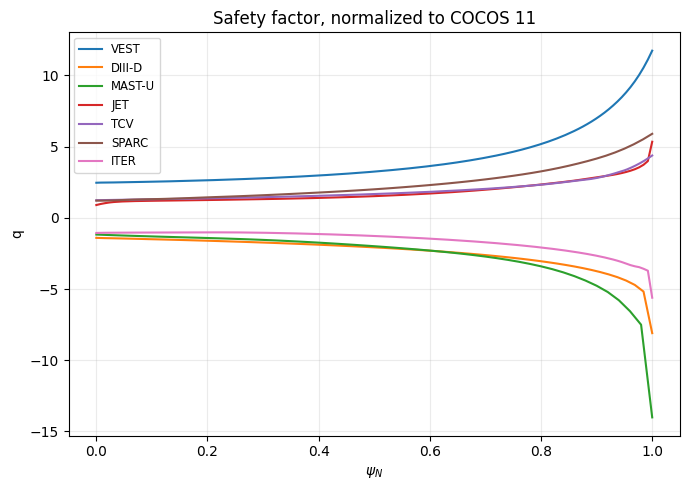

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
for device, eq in normalized.items():
    if eq.q is None or eq.psi_1d is None:
        print(f"{device}: no q(psi) after normalization -- skipped")
        continue
    psi_n = (eq.psi_1d - eq.psi_1d[0]) / (eq.psi_1d[-1] - eq.psi_1d[0])
    ax.plot(psi_n, eq.q, label=device)
ax.set(xlabel=r"$\psi_N$", ylabel="q", title="Safety factor, normalized to COCOS 11")
ax.grid(alpha=0.25)
ax.legend(fontsize="small")
fig.tight_layout()
plt.show()

The signs still differ here -- and after normalization that difference is
physical, not conventional. In COCOS 11 the sign of `q` follows the relative
direction of the plasma current and the toroidal field, so the split above
separates the datasets whose `Ip` and `Bt` are antiparallel from those where
they are not. This is exactly the information the intuitive display drops, which
is why both views are kept:

In [ ]:
print(f"{'device':8s} {'sgn(Ip)':>8s} {'sgn(B0)':>8s} {'product':>8s} {'sgn(q0)':>8s}")
for device, eq in normalized.items():
    if eq.q is None or eq.ip is None or eq.bt0 is None:
        continue
    ip_sign, bt_sign = int(np.sign(eq.ip)), int(np.sign(eq.bt0))
    print(
        f"{device:8s} {ip_sign:>8d} {bt_sign:>8d} {ip_sign * bt_sign:>8d} "
        f"{int(np.sign(eq.q[0])):>8d}"
    )

device    sgn(Ip)  sgn(B0)  product  sgn(q0)
VEST            1        1        1        1
DIII-D          1       -1       -1       -1
MAST-U          1       -1       -1       -1
JET            -1       -1        1        1
TCV            -1       -1        1        1
SPARC          -1       -1        1        1
ITER            1       -1       -1       -1


## What this exercised

- Three input formats -- IMAS netCDF, ODS JSON, GEQDSK -- entered one downstream
  workflow through `vaft.omas.load`, with no per-format handling after loading.
- Seven devices, six of them foreign to VEST, produced global descriptors,
  geometry and profiles through the same convention-aware VAFT APIs.
- Missing IDSs and missing leaves were reported, not filled in, and no device's
  absence broke the comparison.
- COCOS identification genuinely varied across the set (1/2, 11/12, 13/14), and
  normalization was applied explicitly rather than assumed.

## What it did not do

- No dataset was vendored into VAFT and no dataset registry or manifest was
  introduced; the sources above are plain variables with commented alternatives.
- Nothing in the comparison depends on a machine mapping for the foreign
  devices -- only on what their public files already carry.
- The SPARC case is a design equilibrium, not a measurement, and is labelled as
  such wherever it appears.

## Follow-up

The repeated patterns worth promoting out of this notebook are a reusable
public-dataset fetch helper, a multi-machine geometry overview API that overlays
several entries the way the profile renderers already do, and an external-source
availability check that runs somewhere other than a documentation build.